# Manual_Example — 手册主算例: 光阴极枪 + 螺线管, 发射度补偿

本 notebook 是官方算例系列示例之一 (全部位于 examples/ 目录): 只跑这一个官方算例, 逐步解读输入卡、展示本算例最有代表性的图。

In [1]:
%run ../notebooks/_bootstrap.py

astra-notebook 后端已加载 (v0.1.0)
项目根目录: /Users/yuxinwu/my_projects/astra_notebook
模拟工作目录: /Users/yuxinwu/my_projects/astra_notebook/data/workspace
ASTRA    : /Users/yuxinwu/programs/ASTRA/astra
Generator: /Users/yuxinwu/programs/ASTRA/generator


In [2]:
# ===== 共享规格 (单一数据源, 与 06 汇总一致) =====
from examples._examples_spec import (
    EXAMPLES, run_example, phase_files, compare_xemit)
NAME = "Manual_Example"
STEM = "Example"
print("算例:", NAME, "| 物理:", EXAMPLES[NAME]["title"])


算例: Manual_Example | 物理: 手册主算例: 光阴极枪 + 螺线管, 发射度补偿


In [3]:
# ===== 运行本算例 (generator/astra 按需) =====
work = run_example(NAME)
print("输出文件:")
for f in sorted(work.glob(STEM + ".*")):
    print("  ", f.name)

 --------------------------------------------------------------------------

                              generator              
               Version 1.0 - macOS 64bit - Apple Silicon
                        DESY,  Hamburg 2002          
                        Tue Aug 18 01:25:08 

     Working File is:    generator.in                                      
     Initializing        500      electrons
     including 6 probe particles at standard positions
     Particles are quasi randomly distributed

     Final check:
     Particles taken into account      N =        500
     total charge                      Q =     -1.000     nC
     horizontal beam position          x =     2.9867E-04 mm
     vertical beam position            y =     1.6453E-04 mm
     longitudinal beam position        z =     8.5535E-08 m
     horizontal beam size          sig x =     0.7499     mm
     vertical beam size            sig y =     0.7499     mm
     longitudinal beam size        sig z =     0.6595

In [4]:
# ===== 束团统计 (最后一个 z 位置) =====
from astra_tools.io import read_distribution
from astra_tools.analysis.statistics import compute_statistics, print_statistics
from astra_tools.widgets.panels import stats_table_html
ph = phase_files(work, STEM)
dist = read_distribution(ph[-1])
print("相空间文件:", ph[-1].name)
print_statistics(compute_statistics(dist),
                 title="%s @ %s" % (NAME, ph[-1].name))
stats_table_html(compute_statistics(dist))

相空间文件: Example.1500.001

  Manual_Example @ Example.1500.001
  Particles:            500 total,      500 active,      0 passive,
                         0 lost,      0 not started
  Total charge:        1.0000 nC (|Q| shown; sign kept internally)
----------------------------------------
  Ref. momentum:    1000.5000 MeV/c
  Ref. kinetic E:    999.9891 MeV
  gamma:            1957.9299
  beta:              1.000000
----------------------------------------
  Centroid x:          0.0003 mm
  Centroid y:          0.0002 mm
  Centroid z:       1500.0001 mm
  sigma_x:             0.7500 mm
  sigma_y:             0.7497 mm
  sigma_z:             0.6595 mm
----------------------------------------
  Mean pz:          1000.5000 MeV/c
  sigma_p/p:         0.000001
  Mean E_kin:        999.9891 MeV
  sigma_E:             1.4666 keV
  sigma_E/E:         0.000001
----------------------------------------
  eps_x (geom):        0.0010 um.rad
  eps_y (geom):        0.0010 um.rad
  eps_nx:             

quantity,value,unit
n_particle,500,
n_active,500,
n_passive,0,
n_lost,0,
n_not_started,0,
total_charge_nC,1 (|Q|),nC
mean_x_mm,0.000296673,mm
mean_y_mm,0.000167953,mm
mean_z_mm,1500,mm
sig_x_mm,0.749962,mm


### 示例要点

这是手册的主算例: 光阴极枪产生束团, 螺线管做发射度补偿, 追踪到 1.5 m。它生成了全套输出 (Xemit/Zemit/Sigma/相空间), 因此用最全的图组展示。

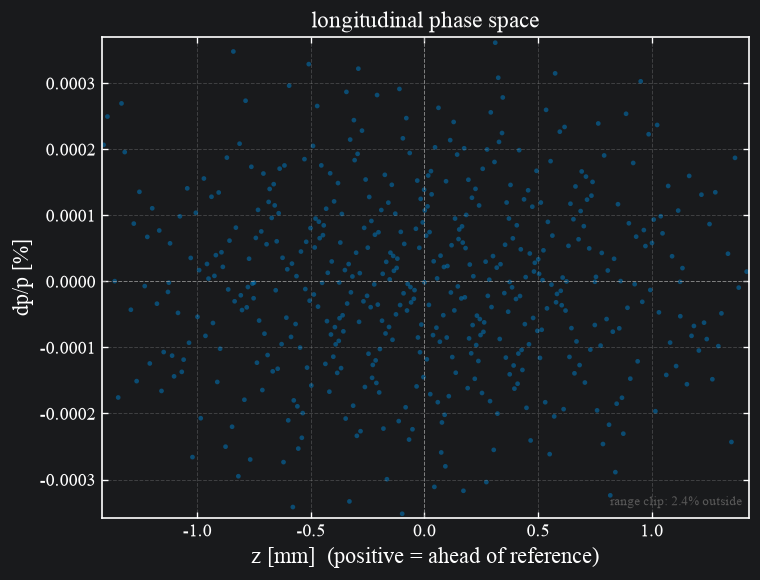

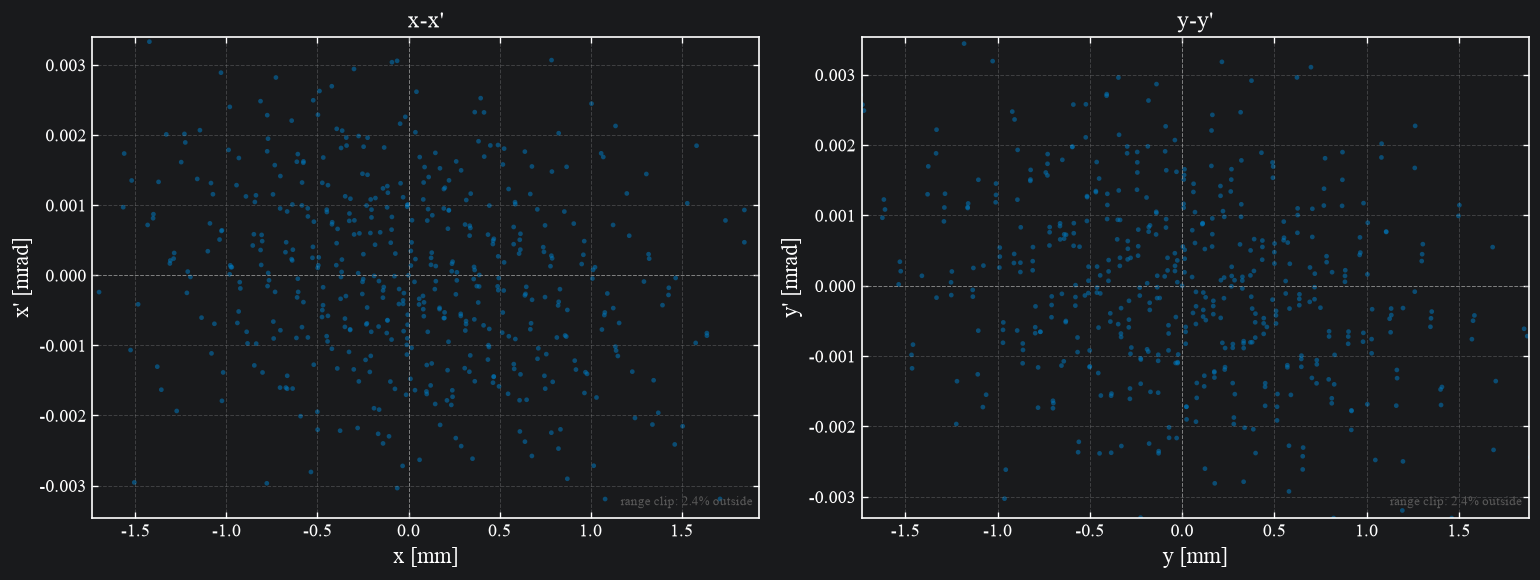

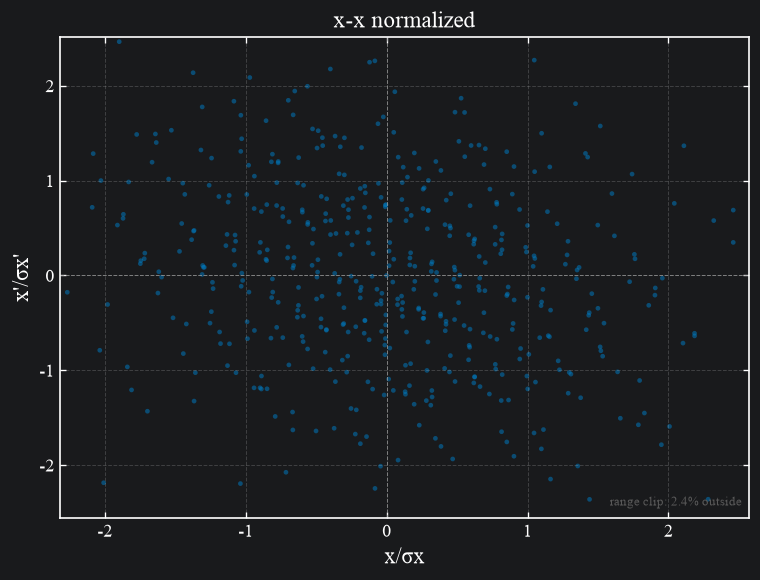

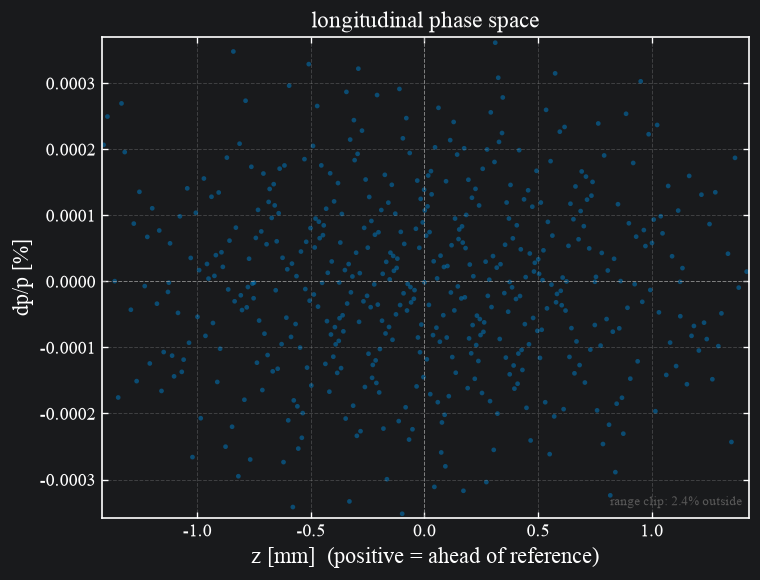

In [5]:
from astra_tools.plot.phase_space import plot_transverse_phase_space, plot_phase_space
# 1 GeV 束流发散角 ~1 urad: 原始图是贴地横线 (物理正确), normalize 后结构可见
plot_transverse_phase_space(dist)
plot_phase_space(dist, plane="x", normalize=True, title="x-x normalized")
plot_phase_space(dist, plane="z")

(<Figure size 1560x1440 with 6 Axes>,
 array([[<Axes: title={'center': "x-x'"}, xlabel='x [mm]', ylabel="x' [mrad]">,
         <Axes: title={'center': 'x-y'}, xlabel='x [mm]', ylabel='y [mm]'>],
        [<Axes: title={'center': "y-y'"}, xlabel='y [mm]', ylabel="y' [mrad]">,
         <Axes: title={'center': 'z-x'}, xlabel='z [mm]', ylabel='x [mm]'>],
        [<Axes: title={'center': 'z-dp/p'}, xlabel='z [mm] (positive = ahead)', ylabel='dp/p [%]'>,
         <Axes: title={'center': 'z-y'}, xlabel='z [mm]', ylabel='y [mm]'>]],
       dtype=object))

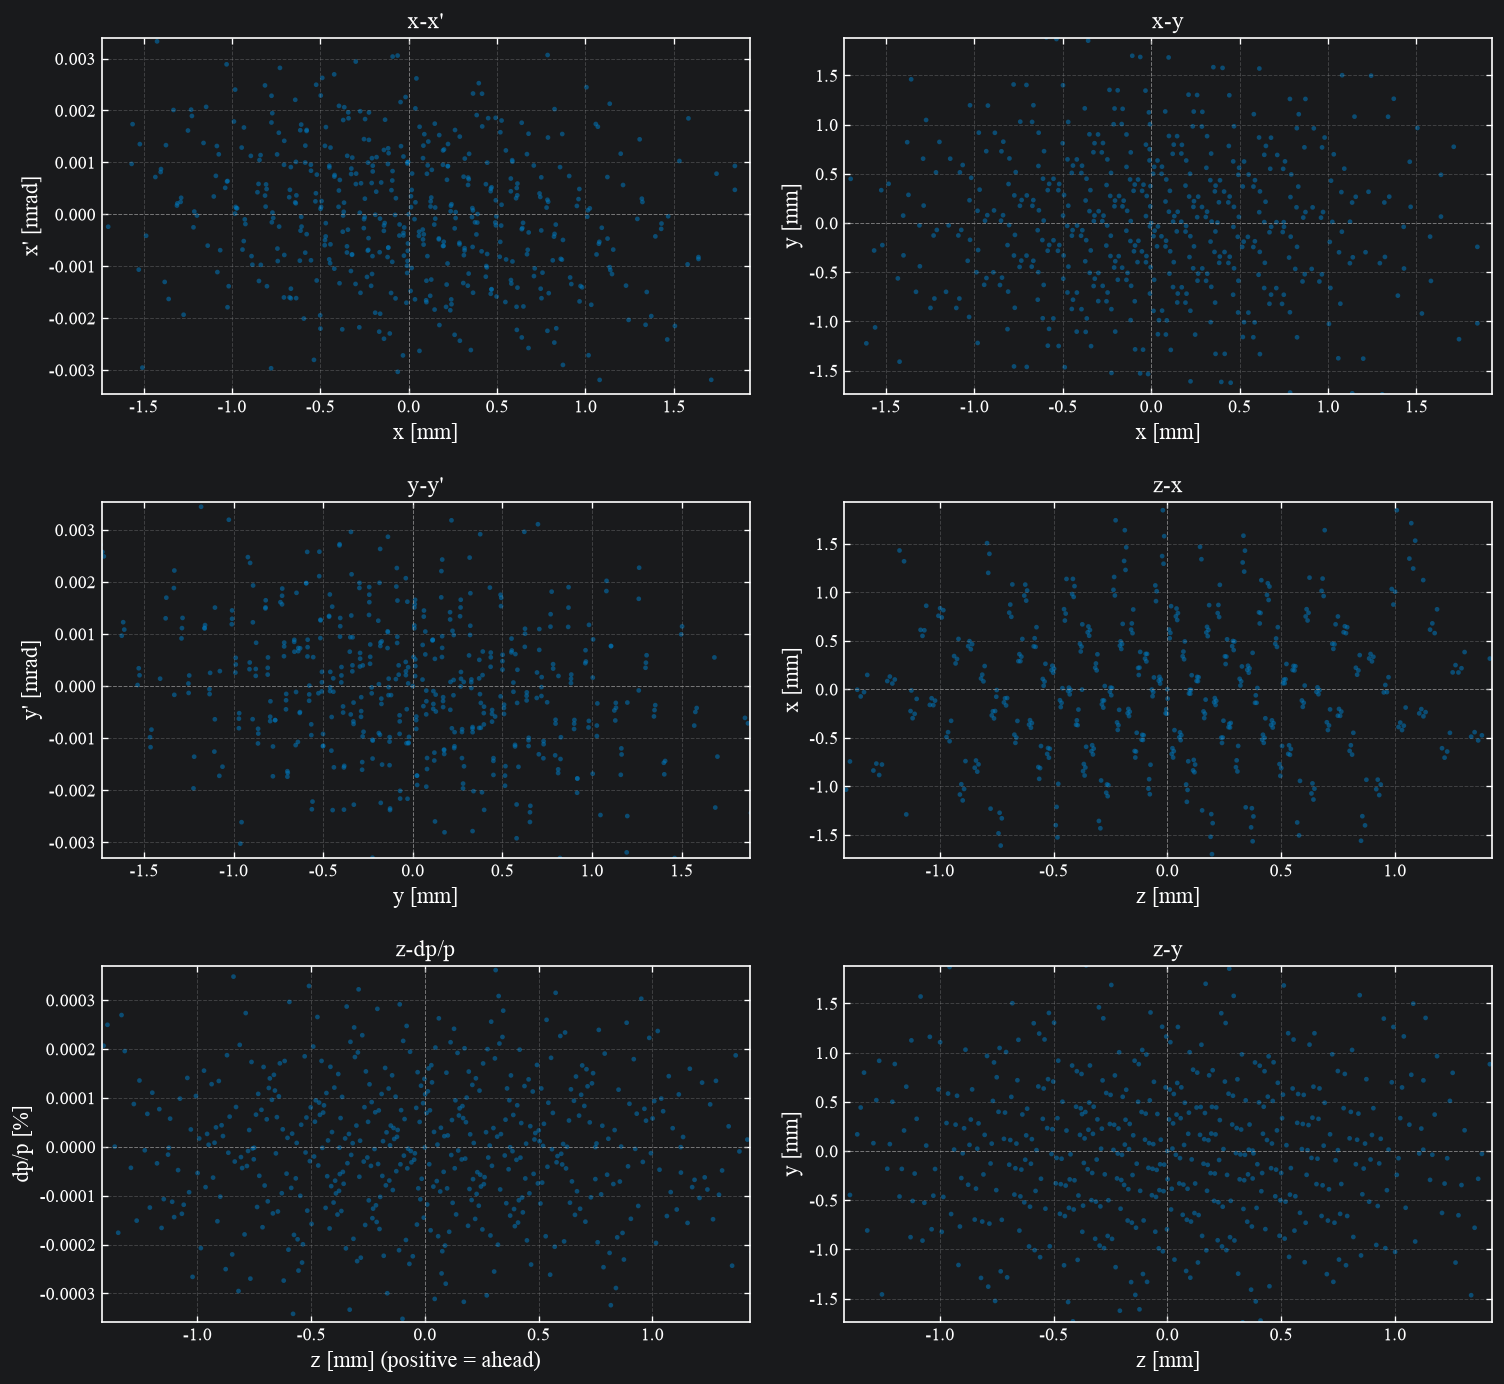

In [6]:
from astra_tools.plot.overview import plot_overview
plot_overview(dist)

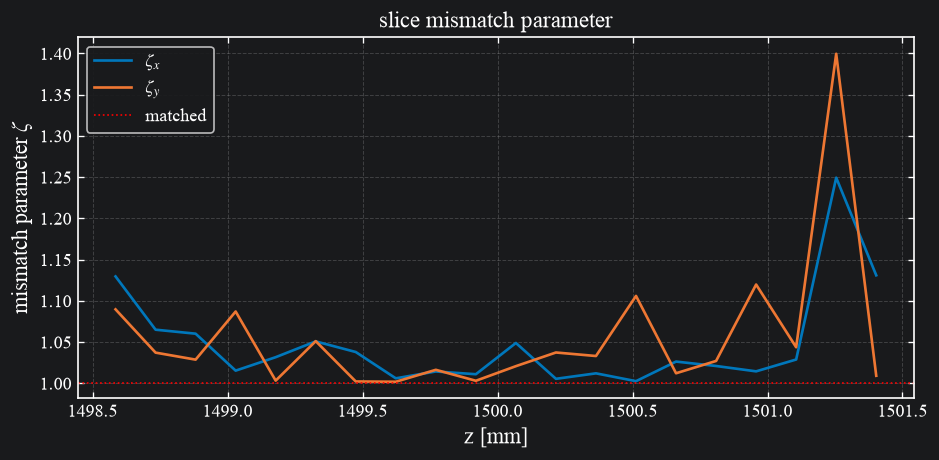

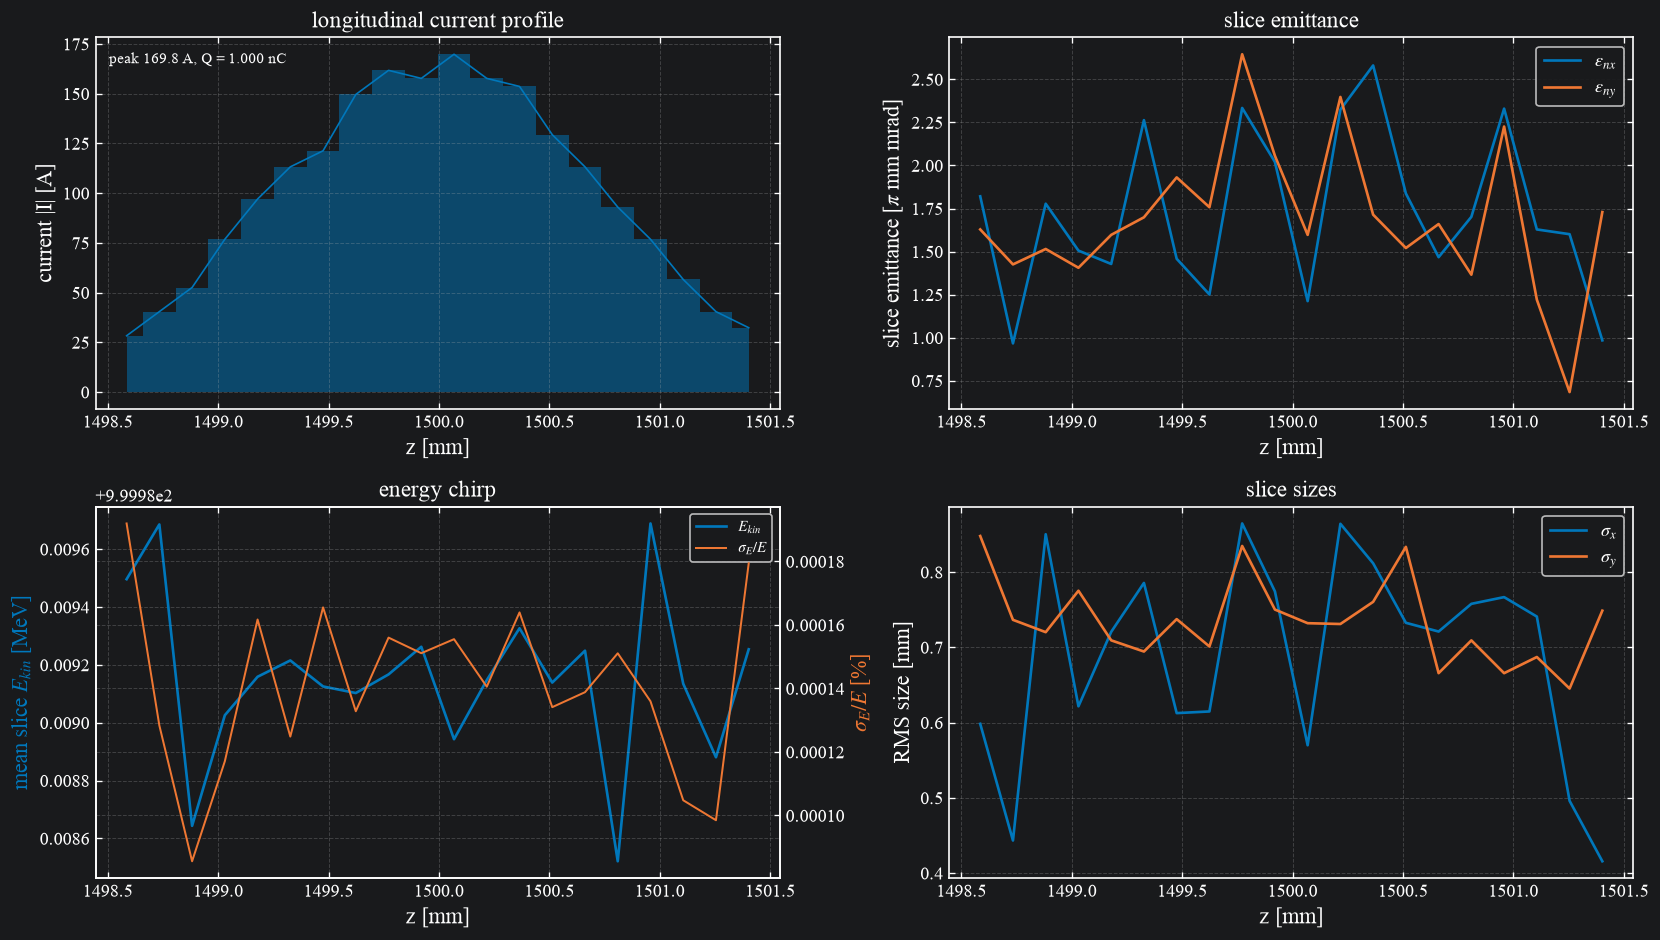

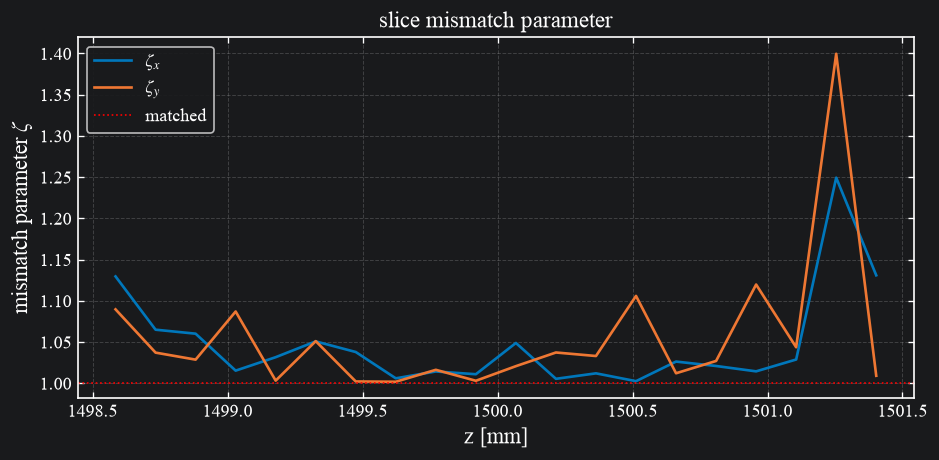

In [7]:
from astra_tools.analysis.slices import compute_slice_analysis
from astra_tools.plot.slice_plots import plot_slice_dashboard
from astra_tools.plot.advanced_plots import plot_slice_mismatch
sa = compute_slice_analysis(dist, n_slices=20)
plot_slice_dashboard(sa)
plot_slice_mismatch(dist, n_slices=20)

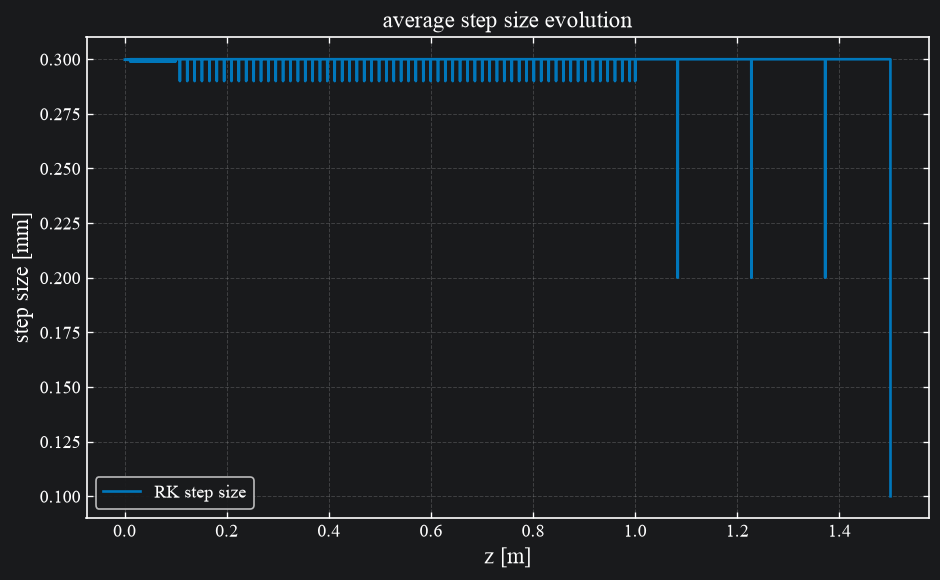

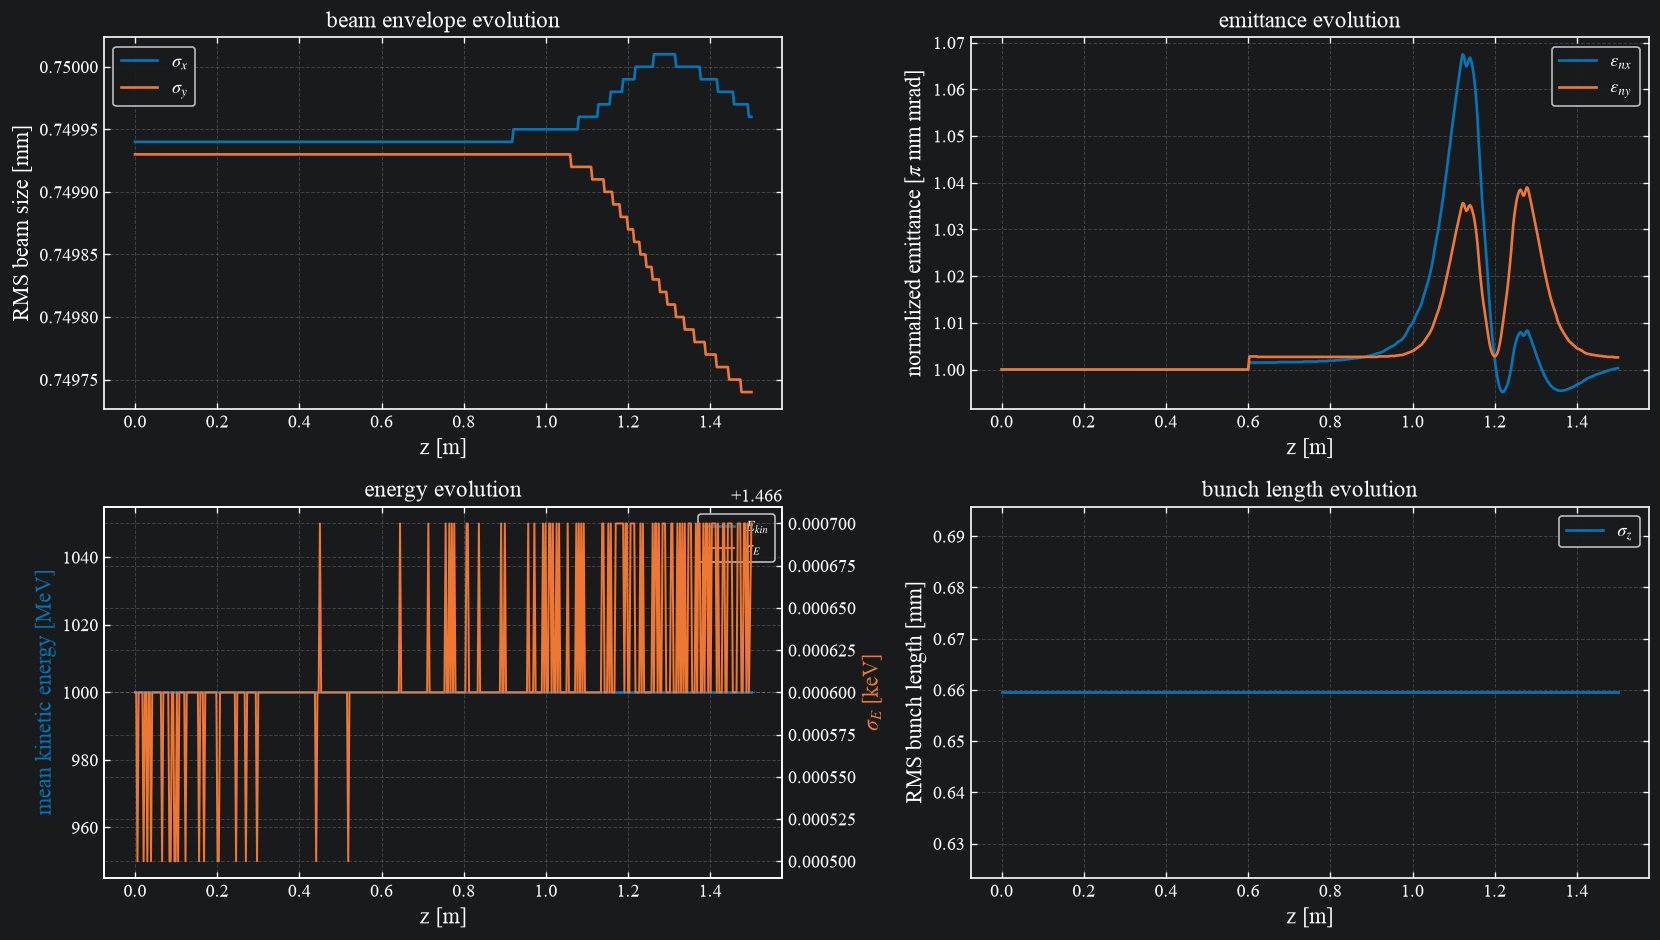

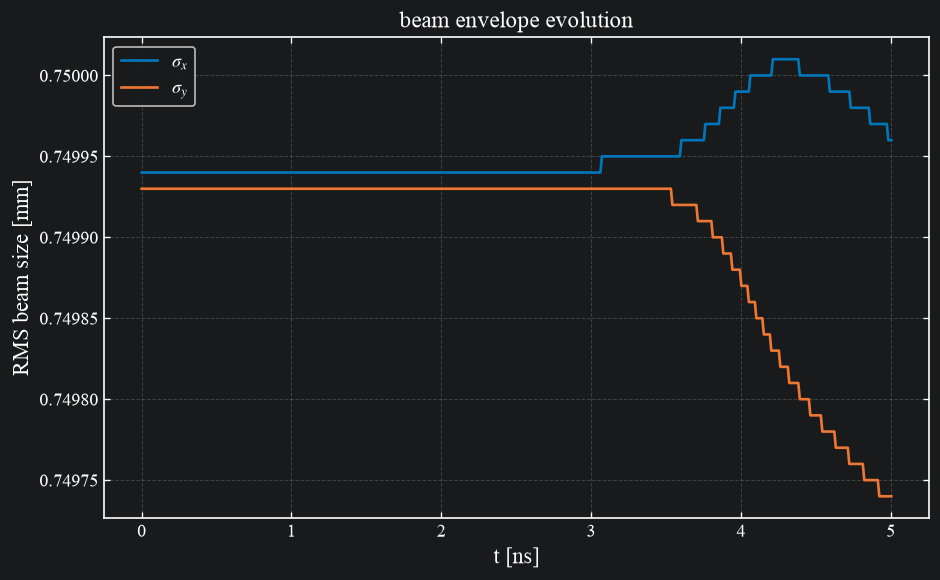

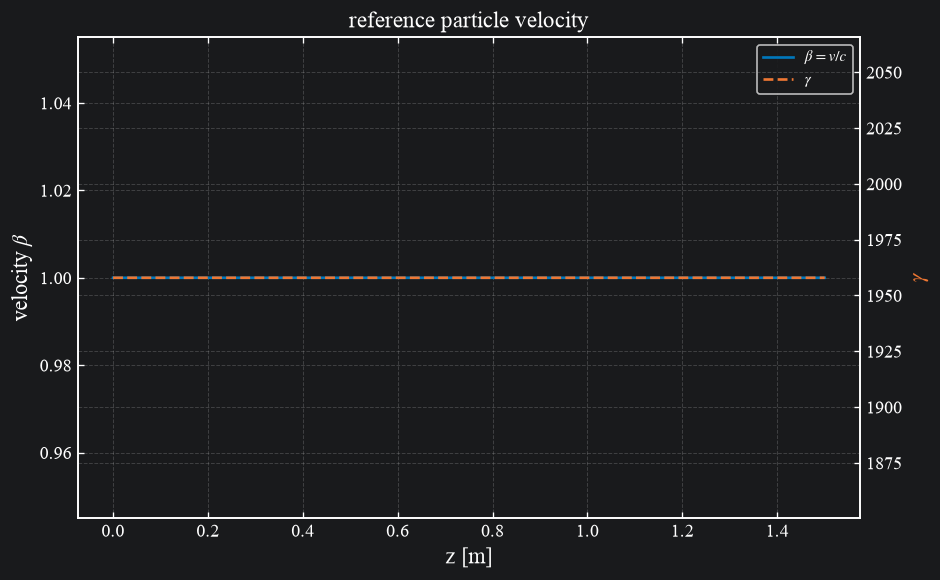

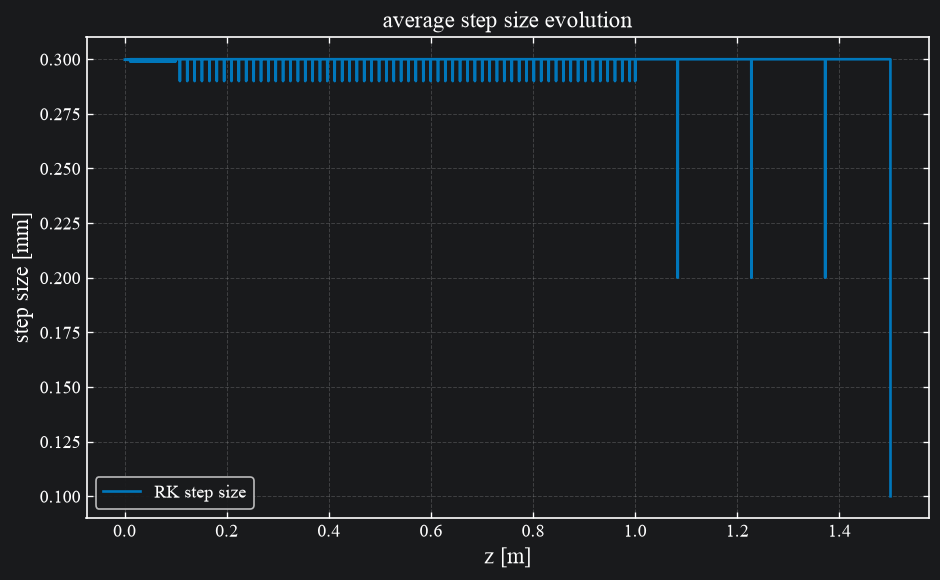

In [8]:
from astra_tools.io.astra_emit import read_emit_files, read_ref_file
from astra_tools.plot.emit_plots import (
    plot_emit_dashboard, plot_envelope_evolution,
    plot_velocity_evolution, plot_step_size_evolution)
emit = read_emit_files(str(work / STEM))
ref = read_ref_file(str(work / STEM))
plot_emit_dashboard(emit)
plot_envelope_evolution(emit, x_axis="t")
plot_velocity_evolution(ref)
plot_step_size_evolution(ref)

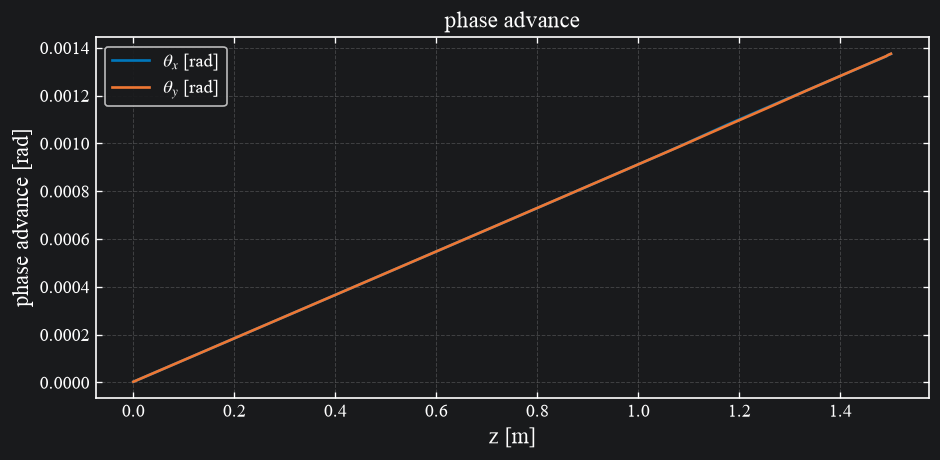

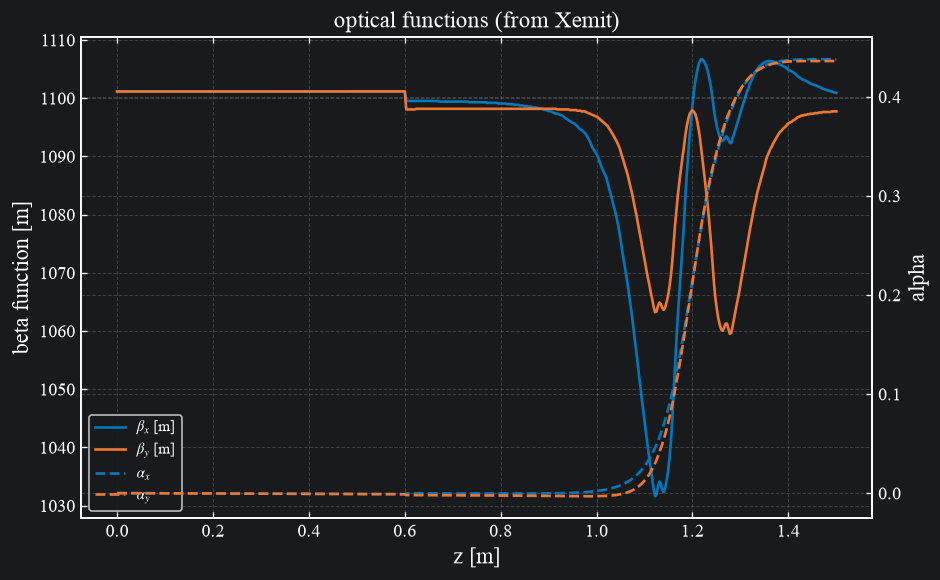

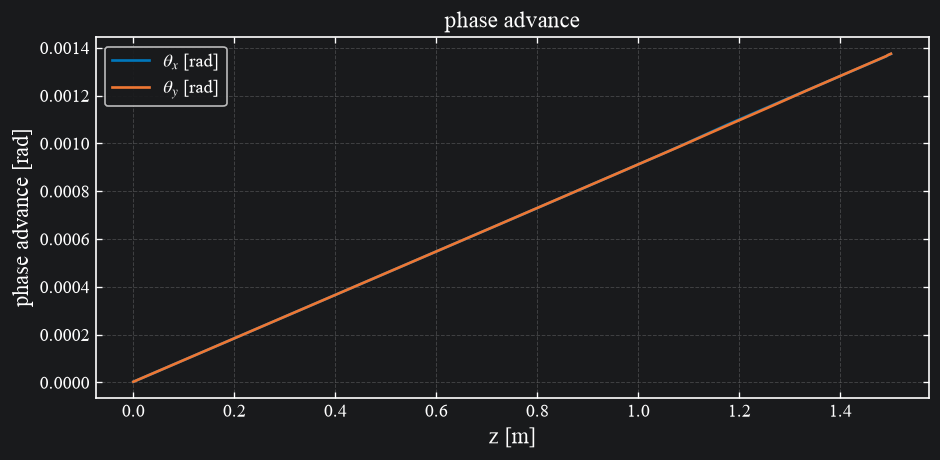

In [9]:
from astra_tools.plot.advanced_plots import plot_beta_alpha, plot_phase_advance
plot_beta_alpha(emit, ref=ref)
plot_phase_advance(emit, ref=ref)

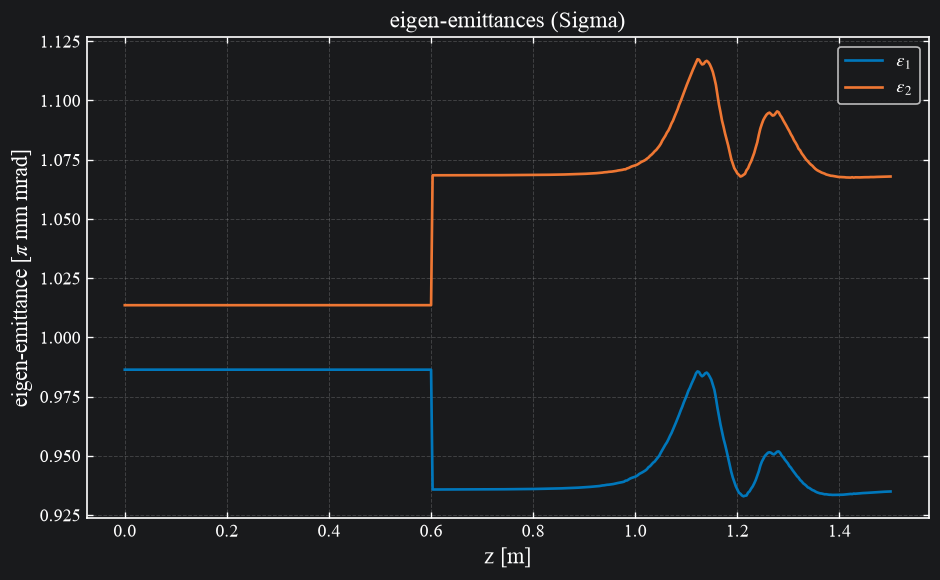

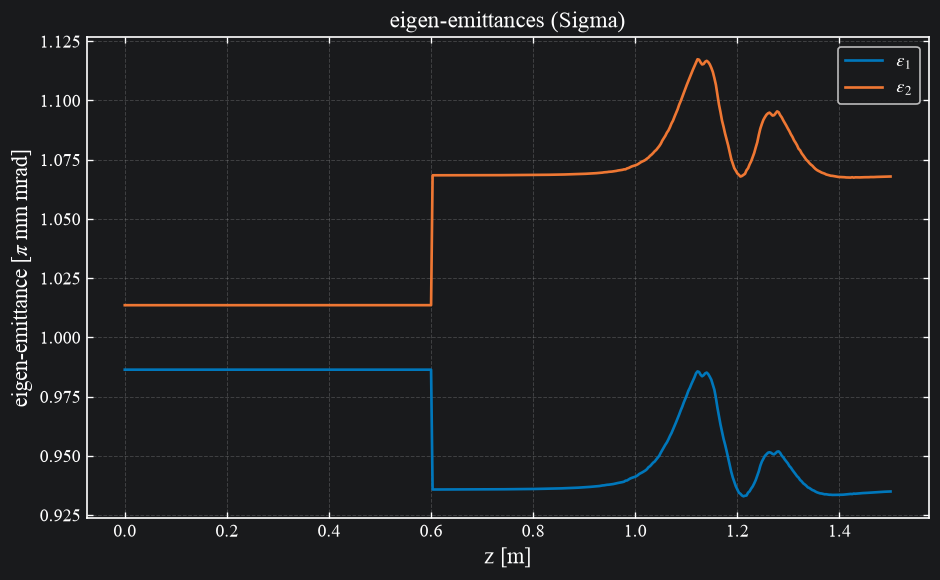

In [10]:
from astra_tools.io.astra_emit import read_sigma_file
from astra_tools.plot.emit_plots import plot_eigen_emittances
sigma = read_sigma_file(str(work / STEM))
plot_eigen_emittances(sigma)  # 动量列/mc 之谜已破解, 与 Xemit 对照 <8%

In [11]:
from astra_tools.export import export_distribution, export_statistics
out = work / "export"
print("导出目录:", out)
print(export_distribution(dist, out))
print(export_statistics(compute_statistics(dist), out))

导出目录: /Users/yuxinwu/my_projects/astra_notebook/data/workspace/Manual_Example/export
{'npz': PosixPath('/Users/yuxinwu/my_projects/astra_notebook/data/workspace/Manual_Example/export/distribution.npz'), 'csv': PosixPath('/Users/yuxinwu/my_projects/astra_notebook/data/workspace/Manual_Example/export/distribution.csv')}
/Users/yuxinwu/my_projects/astra_notebook/data/workspace/Manual_Example/export/statistics.csv


In [12]:
# ===== 黄金比对 (rel < 0.5% 判 OK) =====
compare_xemit(NAME, work)
print("其他官方算例的示例 notebook 同样位于 examples/ 目录")

  末行比对 (new vs golden):
    norm_emit_x    1.0003e-06 1.0003e-06 rel=0.0000% OK
    sigma_x        0.00074996 0.00074996 rel=0.0000% OK
    mean_z         1.5        1.5        rel=0.0000% OK
其他官方算例的示例 notebook 同样位于 examples/ 目录
